# Part 3b — Feature experiments on top of part_3

Test fire feature-udvidelser hver for sig oven på part_3's slutmodel:

- **A:** Hour-of-day dummies × workday (erstatter sin/cos for time)
- **B:** Hour × season interaktioner
- **C:** Day-of-week dummies
- **D:** Hour × temperatur og hour × precipitation

Baseline til sammenligning er part_3's forward-selected model (val RMSE ≈ 124).


### Imports

In [1]:
import pandas as pd
import matplotlib.pyplot as plt
import numpy as np
import scipy as sp
from sklearn.linear_model import *

### Loading Data

In [2]:
df_bike_counts = pd.read_csv('bike_project_data/bike_counts.csv', sep=',', names=["datetime","station","latitude","longitude","bike_count"], header=0)
df_holidays = pd.read_csv('bike_project_data/danish_holidays.csv', sep=',', names=["date","holiday"], header=0)
df_stations = pd.read_csv('bike_project_data/stations.csv', sep=',', names=["station","latitude","longitude","daily_avg_2021"], header=0)
df_weather = pd.read_csv('bike_project_data/weather_copenhagen.csv', sep=',', names=["datetime","temperature_C","wind_speed_ms","precipitation_mm"], header=0)

### Splitting Data - Langebro Station

In [3]:
Station = "Langebro"

df_bike_counts["datetime"] = pd.to_datetime(df_bike_counts["datetime"])
df_weather["datetime"] = pd.to_datetime(df_weather["datetime"])
df_holidays["datetime"] = pd.to_datetime(df_holidays["date"])
df_holidays["holiday"] = True

df_merged = pd.merge(df_bike_counts, df_weather, on="datetime", how="left")

df_merged["date"] = df_merged["datetime"].dt.date
df_holidays["date"] = df_holidays["datetime"].dt.date

df_merged = pd.merge(df_merged, df_holidays[["date", "holiday"]], on="date", how="left")
df_merged["holiday"] = df_merged["holiday"].fillna(False)

df_merged.ffill(inplace=True)

df_training   = df_merged[(df_merged["datetime"].dt.year == 2021) & (df_merged["station"] == Station)].copy()
df_validating = df_merged[(df_merged["datetime"].dt.year == 2022) & (df_merged["station"] == Station)].copy()
df_testing    = df_merged[(df_merged["datetime"].dt.year == 2023) & (df_merged["station"] == Station)].copy()

C:\Users\Bruger\AppData\Local\Temp\ipykernel_15588\2438475919.py:14: FutureWarning: Downcasting object dtype arrays on .fillna, .ffill, .bfill is deprecated and will change in a future version. Call result.infer_objects(copy=False) instead. To opt-in to the future behavior, set `pd.set_option('future.no_silent_downcasting', True)`
  df_merged["holiday"] = df_merged["holiday"].fillna(False)


### Helper functions
Same style as part_2 — with two fixes:
- `ridge_reg` now uses `X.shape[1]` (number of features), not `X.shape[0]`.
- `calculate_RMSE` uses **mean**, so train / val / test errors are comparable.

In [4]:
def linear_reg(X, y):
    return np.linalg.solve(X.T @ X, X.T @ y)

def ridge_reg(X, y, lam):
    return np.linalg.solve(X.T @ X + lam * np.eye(X.shape[1]), X.T @ y)

def calculate_RMSE(X, w, y_true):
    y_pred = np.maximum((X @ w).flatten(), 0)
    return np.sqrt(np.mean((y_pred - y_true) ** 2))

def standardize_train(X):
    # leave intercept (col 0) untouched
    mu = X[:, 1:].mean(axis=0)
    sigma = X[:, 1:].std(axis=0)
    sigma = np.where(sigma == 0, 1.0, sigma)
    X_std = X.copy().astype(float)
    X_std[:, 1:] = (X[:, 1:] - mu) / sigma
    return X_std, mu, sigma

def standardize_apply(X, mu, sigma):
    X_std = X.copy().astype(float)
    X_std[:, 1:] = (X[:, 1:] - mu) / sigma
    return X_std

### Feature engineering — generate all candidates
Extends `build_system` from part_2:
- hour harmonics k=1..6 (higher k = sharper peaks for commute)
- dayofyear cycle, first AND second harmonic (uses `dayofyear`, fixes the `dt.day / 365` bug)
- day-of-week cycle, weekend / holiday / workday indicators
- quadratic temp / wind, log(1+precip), is_raining
- hour × workday for **all** harmonics (commute spikes only on workdays)
- temp / precip / wind × workday (commuters react to weather differently than weekend cyclists)

In [5]:
def add_features(df):
    df = df.copy()
    h   = df["datetime"].dt.hour
    doy = df["datetime"].dt.dayofyear
    dow = df["datetime"].dt.dayofweek

    # cyclical hour at multiple harmonics — k up to 6 captures sharp commute spikes
    for k in [1, 2, 3, 4, 5, 6]:
        df[f"h_sin{k}"] = np.sin(2 * np.pi * k * h / 24)
        df[f"h_cos{k}"] = np.cos(2 * np.pi * k * h / 24)

    # seasonal cycle — first and second harmonic of dayofyear
    df["d_sin1"] = np.sin(2 * np.pi * doy / 365)
    df["d_cos1"] = np.cos(2 * np.pi * doy / 365)
    df["d_sin2"] = np.sin(4 * np.pi * doy / 365)
    df["d_cos2"] = np.cos(4 * np.pi * doy / 365)

    # day of week (cyclical)
    df["dow_sin"] = np.sin(2 * np.pi * dow / 7)
    df["dow_cos"] = np.cos(2 * np.pi * dow / 7)

    # calendar indicators
    df["is_weekend"] = (dow >= 5).astype(float)
    df["is_holiday"] = df["holiday"].astype(float)
    df["is_workday"] = ((1 - df["is_weekend"]) * (1 - df["is_holiday"])).astype(float)

    # weather
    df["temp"]       = df["temperature_C"]
    df["temp_sq"]    = df["temperature_C"] ** 2
    df["wind"]       = df["wind_speed_ms"]
    df["wind_sq"]    = df["wind_speed_ms"] ** 2
    df["precip"]     = df["precipitation_mm"]
    df["log_precip"] = np.log1p(df["precipitation_mm"])
    df["is_raining"] = (df["precipitation_mm"] > 0.1).astype(float)

    # commute interactions: hour × workday for ALL harmonics
    for k in [1, 2, 3, 4, 5, 6]:
        df[f"h_sin{k}_wd"] = df[f"h_sin{k}"] * df["is_workday"]
        df[f"h_cos{k}_wd"] = df[f"h_cos{k}"] * df["is_workday"]

    # weather × workday interactions
    df["temp_wd"]   = df["temp"] * df["is_workday"]
    df["precip_wd"] = df["precip"] * df["is_workday"]
    df["wind_wd"]   = df["wind"] * df["is_workday"]

    return df


df_training   = add_features(df_training)
df_validating = add_features(df_validating)
df_testing    = add_features(df_testing)


def build_X(df, feature_names):
    n = df.shape[0]
    cols = [np.ones(n)]
    for name in feature_names:
        cols.append(df[name].values.astype(float))
    return np.column_stack(cols)


y_tr = df_training["bike_count"].values
y_va = df_validating["bike_count"].values
y_te = df_testing["bike_count"].values

### Helper — residual diagnostics


In [6]:
def plot_residuals(df_, residuals, title):
    fig, axes = plt.subplots(2, 3, figsize=(14, 8))
    axes[0,0].scatter(df_["datetime"].dt.hour,        residuals, alpha=0.2, s=4)
    axes[0,0].set_xlabel("hour");           axes[0,0].set_ylabel("residual")
    axes[0,1].scatter(df_["datetime"].dt.dayofweek,   residuals, alpha=0.2, s=4)
    axes[0,1].set_xlabel("day of week")
    axes[0,2].scatter(df_["datetime"].dt.dayofyear,   residuals, alpha=0.2, s=4)
    axes[0,2].set_xlabel("day of year")
    axes[1,0].scatter(df_["temperature_C"],           residuals, alpha=0.2, s=4)
    axes[1,0].set_xlabel("temperature (C)"); axes[1,0].set_ylabel("residual")
    axes[1,1].scatter(df_["wind_speed_ms"],           residuals, alpha=0.2, s=4)
    axes[1,1].set_xlabel("wind (m/s)")
    axes[1,2].scatter(df_["precipitation_mm"],        residuals, alpha=0.2, s=4)
    axes[1,2].set_xlabel("precipitation (mm)")
    for ax in axes.flat:
        ax.axhline(0, color="red", linewidth=0.8)
    fig.suptitle(title)
    plt.tight_layout()
    plt.show()


### Feature groups and evaluator (genbrug fra part_3)


In [7]:
feature_groups = {
    "hour_24":       ["h_sin1", "h_cos1"],
    "hour_12":       ["h_sin2", "h_cos2"],
    "hour_8":        ["h_sin3", "h_cos3"],
    "hour_6":        ["h_sin4", "h_cos4"],
    "hour_4_8":      ["h_sin5", "h_cos5"],
    "hour_4":        ["h_sin6", "h_cos6"],
    "dayofyear_1":   ["d_sin1", "d_cos1"],
    "dayofyear_2":   ["d_sin2", "d_cos2"],
    "dayofweek":     ["dow_sin", "dow_cos"],
    "is_weekend":    ["is_weekend"],
    "is_holiday":    ["is_holiday"],
    "is_workday":    ["is_workday"],
    "temp":          ["temp"],
    "temp_sq":       ["temp_sq"],
    "wind":          ["wind"],
    "wind_sq":       ["wind_sq"],
    "precip":        ["precip"],
    "log_precip":    ["log_precip"],
    "is_raining":    ["is_raining"],
    "hour24_x_wd":   ["h_sin1_wd", "h_cos1_wd"],
    "hour12_x_wd":   ["h_sin2_wd", "h_cos2_wd"],
    "hour8_x_wd":    ["h_sin3_wd", "h_cos3_wd"],
    "hour6_x_wd":    ["h_sin4_wd", "h_cos4_wd"],
    "hour4_8_x_wd":  ["h_sin5_wd", "h_cos5_wd"],
    "hour4_x_wd":    ["h_sin6_wd", "h_cos6_wd"],
    "temp_x_wd":     ["temp_wd"],
    "precip_x_wd":   ["precip_wd"],
    "wind_x_wd":     ["wind_wd"],
}

y_tr = df_training["bike_count"].values
y_va = df_validating["bike_count"].values
y_te = df_testing["bike_count"].values

def eval_features(feat_names, lam=0.0):
    X_tr = build_X(df_training,   feat_names)
    X_va = build_X(df_validating, feat_names)
    X_tr_s, mu, sigma = standardize_train(X_tr)
    X_va_s = standardize_apply(X_va, mu, sigma)
    try:
        w = ridge_reg(X_tr_s, y_tr, lam)
    except np.linalg.LinAlgError:
        return np.inf  # rank-deficient combination — skip
    return calculate_RMSE(X_va_s, w, y_va)


## 1. Reference-baseline — gendan part_3's slutmodel

Kør forward selection som i part_3. Output: `selected_features_p3` og baseline RMSE'er der bliver målestokken for alle eksperimenter.


In [8]:
def forward_select(groups_dict, lam=0.0, verbose=False):
    selected_groups, selected_features = [], []
    remaining = list(groups_dict.keys())
    best_rmse = eval_features([], lam=lam)
    history = [("(intercept only)", best_rmse)]
    while remaining:
        best_g, best_g_rmse = None, best_rmse
        for g in remaining:
            trial = selected_features + groups_dict[g]
            rmse = eval_features(trial, lam=lam)
            if rmse < best_g_rmse:
                best_g_rmse, best_g = rmse, g
        if best_g is None:
            break
        selected_groups.append(best_g)
        selected_features += groups_dict[best_g]
        remaining.remove(best_g)
        best_rmse = best_g_rmse
        history.append((best_g, best_rmse))
    if verbose:
        for g, r in history:
            print(f"{g:25s}  val RMSE = {r:.2f}")
    return selected_groups, selected_features, history

selected_groups_p3, selected_features_p3, history_p3 = forward_select(
    feature_groups, lam=0.0, verbose=True)
print(f"\nSelected groups (part_3): {selected_groups_p3}")


(intercept only)           val RMSE = 259.81
temp_x_wd                  val RMSE = 217.31
hour_24                    val RMSE = 191.17
hour_8                     val RMSE = 170.57
hour12_x_wd                val RMSE = 156.59
dayofyear_1                val RMSE = 146.37
hour_4_8                   val RMSE = 136.78
hour4_x_wd                 val RMSE = 133.15
hour24_x_wd                val RMSE = 130.46
hour_12                    val RMSE = 129.29
hour8_x_wd                 val RMSE = 127.92
wind                       val RMSE = 126.78
precip                     val RMSE = 126.10
hour4_8_x_wd               val RMSE = 125.62
hour_4                     val RMSE = 125.09
temp                       val RMSE = 124.77
hour6_x_wd                 val RMSE = 124.54
dayofyear_2                val RMSE = 124.50
hour_6                     val RMSE = 124.48
precip_x_wd                val RMSE = 124.46
log_precip                 val RMSE = 124.46
wind_sq                    val RMSE = 124.46

Selected 

In [9]:
# Train reference model and compute train/val/test RMSE
X_tr = build_X(df_training,   selected_features_p3)
X_va = build_X(df_validating, selected_features_p3)
X_te = build_X(df_testing,    selected_features_p3)
X_tr_s, mu_ref, sigma_ref = standardize_train(X_tr)
X_va_s = standardize_apply(X_va, mu_ref, sigma_ref)
X_te_s = standardize_apply(X_te, mu_ref, sigma_ref)

w_ref = ridge_reg(X_tr_s, y_tr, 0.0)
ref_train = calculate_RMSE(X_tr_s, w_ref, y_tr)
ref_val   = calculate_RMSE(X_va_s, w_ref, y_va)
ref_test  = calculate_RMSE(X_te_s, w_ref, y_te)
print(f"Reference (part_3)  train={ref_train:.2f}  val={ref_val:.2f}  test={ref_test:.2f}")

baseline_residuals_va = y_va - np.maximum((X_va_s @ w_ref).flatten(), 0)


Reference (part_3)  train=114.12  val=124.46  test=124.18


## 2. Diagnostik — residualstruktur ved time 8 og 17

Plot baseline-residualer ved problematiske timer mod måned, day-of-week, temp, og precip. Hvis residualerne stadig korrelerer med disse, mangler vi en interaktion.


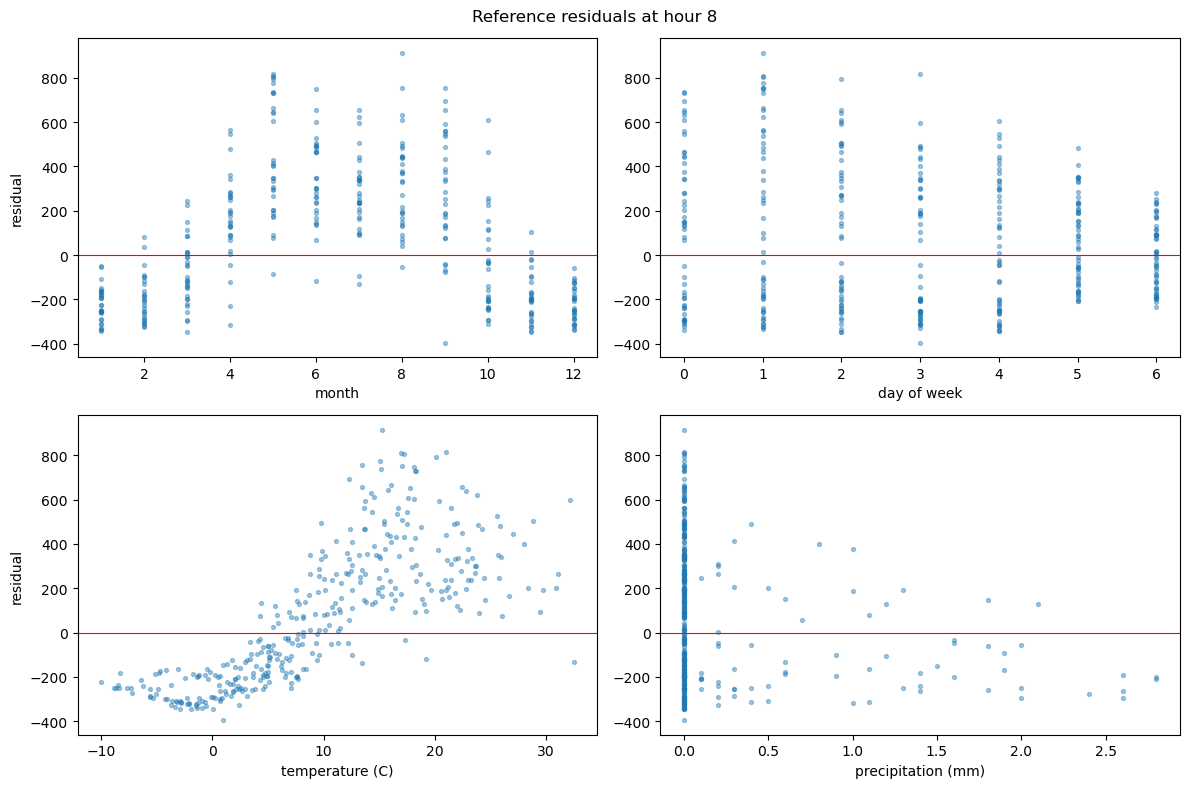

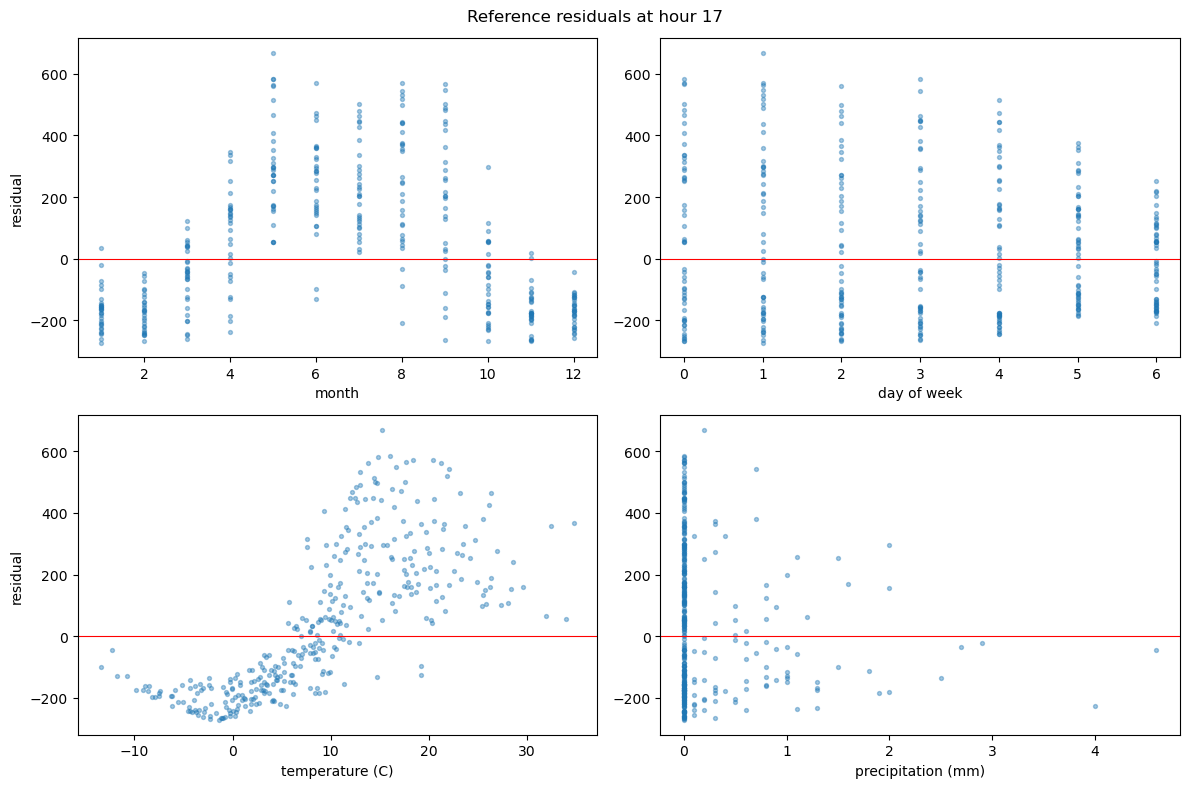

In [10]:
for target_hour in [8, 17]:
    mask = df_validating["datetime"].dt.hour == target_hour
    df_h = df_validating.loc[mask]
    resid_h = baseline_residuals_va[mask.values]

    fig, axes = plt.subplots(2, 2, figsize=(12, 8))
    axes[0,0].scatter(df_h["datetime"].dt.month,     resid_h, alpha=0.4, s=8)
    axes[0,0].set_xlabel("month");           axes[0,0].set_ylabel("residual")
    axes[0,1].scatter(df_h["datetime"].dt.dayofweek, resid_h, alpha=0.4, s=8)
    axes[0,1].set_xlabel("day of week")
    axes[1,0].scatter(df_h["temperature_C"],         resid_h, alpha=0.4, s=8)
    axes[1,0].set_xlabel("temperature (C)");  axes[1,0].set_ylabel("residual")
    axes[1,1].scatter(df_h["precipitation_mm"],      resid_h, alpha=0.4, s=8)
    axes[1,1].set_xlabel("precipitation (mm)")
    for ax in axes.flat:
        ax.axhline(0, color="red", linewidth=0.8)
    fig.suptitle(f"Reference residuals at hour {target_hour}")
    plt.tight_layout()
    plt.show()


## 3. Generer nye eksperimentelle features

Tilføj alle kandidater til de tre dataframes på én gang så hvert eksperiment kun skal vælge fra en liste.


In [11]:
def add_experimental_features(df):
    df = df.copy()
    h   = df["datetime"].dt.hour
    dow = df["datetime"].dt.dayofweek

    # A: hour-of-day dummies and dummy x workday (drop hour 0 as reference)
    for hh in range(1, 24):
        df[f"is_hour_{hh}"]    = (h == hh).astype(float)
        df[f"is_hour_{hh}_wd"] = df[f"is_hour_{hh}"] * df["is_workday"]

    # B: hour x season (k=1,2 with d=1,2)
    for k in [1, 2]:
        for s in [1, 2]:
            df[f"h_sin{k}_x_d_sin{s}"] = df[f"h_sin{k}"] * df[f"d_sin{s}"]
            df[f"h_sin{k}_x_d_cos{s}"] = df[f"h_sin{k}"] * df[f"d_cos{s}"]
            df[f"h_cos{k}_x_d_sin{s}"] = df[f"h_cos{k}"] * df[f"d_sin{s}"]
            df[f"h_cos{k}_x_d_cos{s}"] = df[f"h_cos{k}"] * df[f"d_cos{s}"]

    # C: day-of-week dummies (drop Monday=0 as reference)
    for d in range(1, 7):
        df[f"is_dow_{d}"] = (dow == d).astype(float)

    # D: hour x weather (k=1,2)
    for k in [1, 2]:
        df[f"h_sin{k}_x_temp"]   = df[f"h_sin{k}"] * df["temp"]
        df[f"h_cos{k}_x_temp"]   = df[f"h_cos{k}"] * df["temp"]
        df[f"h_sin{k}_x_precip"] = df[f"h_sin{k}"] * df["precip"]
        df[f"h_cos{k}_x_precip"] = df[f"h_cos{k}"] * df["precip"]

    return df

df_training   = add_experimental_features(df_training)
df_validating = add_experimental_features(df_validating)
df_testing    = add_experimental_features(df_testing)

# Convenience name lists
hour_dummy_feats     = [f"is_hour_{hh}"    for hh in range(1, 24)]
hour_dummy_wd_feats  = [f"is_hour_{hh}_wd" for hh in range(1, 24)]
hour_x_season_feats  = [f"h_{t}{k}_x_d_{u}{s}"
                        for k in [1,2] for s in [1,2]
                        for t in ["sin","cos"] for u in ["sin","cos"]]
dow_dummy_feats      = [f"is_dow_{d}" for d in range(1, 7)]
hour_x_temp_feats    = [f"h_{t}{k}_x_temp"   for k in [1,2] for t in ["sin","cos"]]
hour_x_precip_feats  = [f"h_{t}{k}_x_precip" for k in [1,2] for t in ["sin","cos"]]

n_new = (len(hour_dummy_feats) + len(hour_dummy_wd_feats) + len(hour_x_season_feats)
         + len(dow_dummy_feats) + len(hour_x_temp_feats) + len(hour_x_precip_feats))
print(f"Added {n_new} experimental features per dataframe")


Added 76 experimental features per dataframe


### Hjælpefunktion — træn og rapportér på et vilkårligt feature-sæt


In [12]:
def fit_and_score(feat_names, lam=0.0, label="model"):
    X_tr = build_X(df_training,   feat_names)
    X_va = build_X(df_validating, feat_names)
    X_te = build_X(df_testing,    feat_names)
    X_tr_s, mu, sigma = standardize_train(X_tr)
    X_va_s = standardize_apply(X_va, mu, sigma)
    X_te_s = standardize_apply(X_te, mu, sigma)
    w = ridge_reg(X_tr_s, y_tr, lam)
    tr = calculate_RMSE(X_tr_s, w, y_tr)
    va = calculate_RMSE(X_va_s, w, y_va)
    te = calculate_RMSE(X_te_s, w, y_te)
    print(f"{label:35s}  train={tr:.2f}  val={va:.2f}  test={te:.2f}  (n_feat={len(feat_names)})")
    resid = y_va - np.maximum((X_va_s @ w).flatten(), 0)
    return {"label": label, "train": tr, "val": va, "test": te,
            "w": w, "feats": feat_names, "resid_va": resid}


## 4. Eksperiment A — Hour-of-day dummies × workday

Erstat alle hour-harmoniske features (`h_sin*`, `h_cos*`, `h_sin*_wd`, `h_cos*_wd`) med 23 hour-dummies + 23 hour-dummies × workday = 46 features. Hour 0 er referencekategori.


In [13]:
hour_harm_feats    = [f for k in [1,2,3,4,5,6] for f in [f"h_sin{k}", f"h_cos{k}"]]
hour_harm_wd_feats = [f for k in [1,2,3,4,5,6] for f in [f"h_sin{k}_wd", f"h_cos{k}_wd"]]
to_drop = set(hour_harm_feats + hour_harm_wd_feats)

feats_A = [f for f in selected_features_p3 if f not in to_drop] \
          + hour_dummy_feats + hour_dummy_wd_feats

res_A = fit_and_score(feats_A, lam=0.0, label="A: hour dummies x wd")


A: hour dummies x wd                 train=112.51  val=123.04  test=123.01  (n_feat=57)


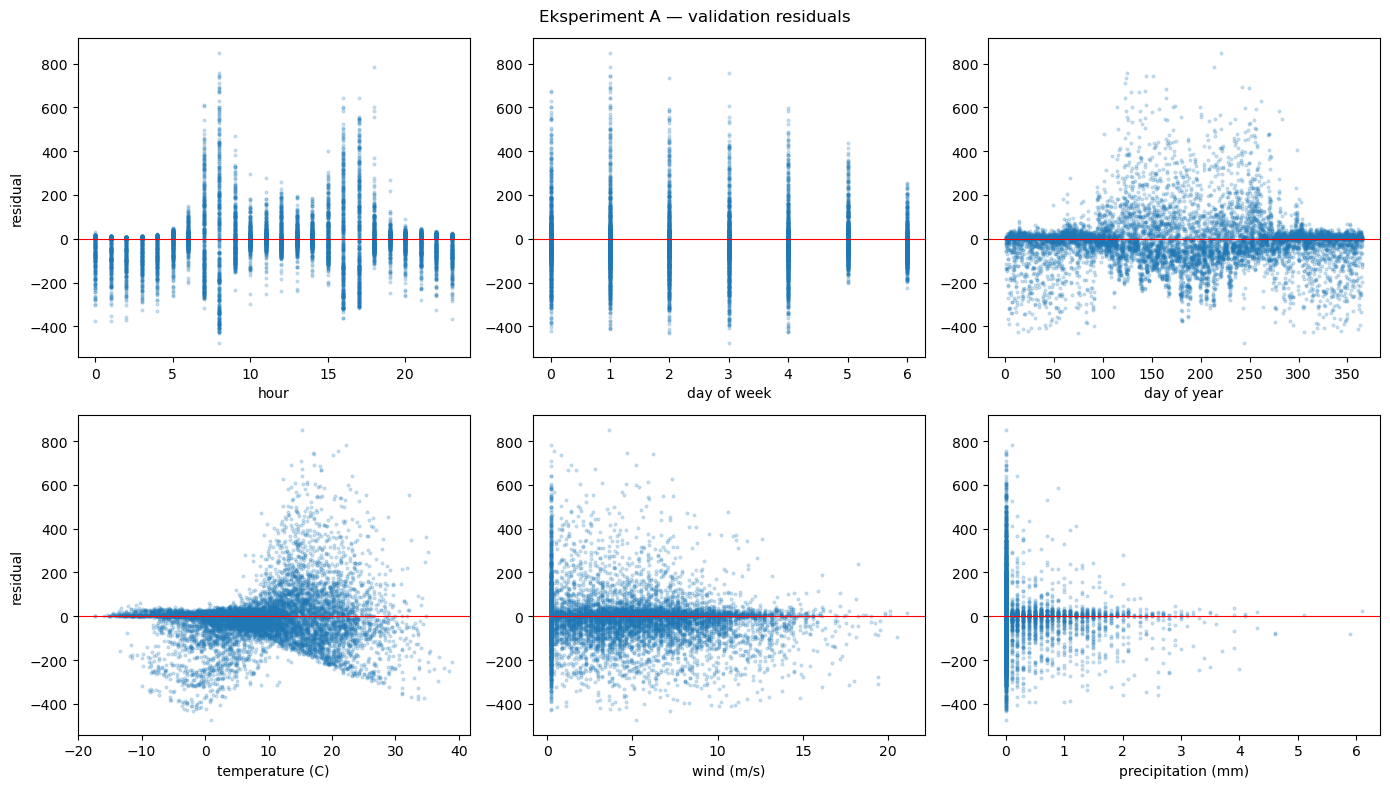

In [14]:
plot_residuals(df_validating, res_A["resid_va"], "Eksperiment A — validation residuals")


## 5. Eksperiment B — Hour × season interaktioner

Tilføj 16 produkter af hour-harmoniske (k=1,2) med dayofyear-harmoniske (s=1,2) til part_3's selected features.


In [15]:
feats_B = list(selected_features_p3) + hour_x_season_feats
res_B = fit_and_score(feats_B, lam=0.0, label="B: hour x season")


B: hour x season                     train=95.25  val=103.92  test=103.64  (n_feat=51)


## 6. Eksperiment C — Day-of-week dummies

Tilføj 6 binære dow-dummies (Monday=0 som reference). Beholder `is_workday` for at bevare hour×wd-interaktionerne; dummies fanger hovedeffekt-variation mellem ugedage (fx fredag ≠ tirsdag).


In [16]:
feats_C = list(selected_features_p3) + dow_dummy_feats
res_C = fit_and_score(feats_C, lam=0.0, label="C: dow dummies")


C: dow dummies                       train=113.86  val=124.42  test=124.43  (n_feat=41)


## 7. Eksperiment D — Hour × temperatur og hour × precipitation

Tilføj 8 produkter af hour-harmoniske (k=1,2) med temp og 8 med precip = 16 nye features.


In [17]:
feats_D = list(selected_features_p3) + hour_x_temp_feats + hour_x_precip_feats
res_D = fit_and_score(feats_D, lam=0.0, label="D: hour x temp + precip")


D: hour x temp + precip              train=93.84  val=101.93  test=101.75  (n_feat=43)


## 8. Sammenligning af enkelt-eksperimenter


model                                  train      val     test    d val
-----------------------------------------------------------------------
Reference (part_3)                    114.12   124.46   124.18    +0.00
A: hour dummies x wd                  112.51   123.04   123.01    -1.42
B: hour x season                       95.25   103.92   103.64   -20.54
C: dow dummies                        113.86   124.42   124.43    -0.04
D: hour x temp + precip                93.84   101.93   101.75   -22.53


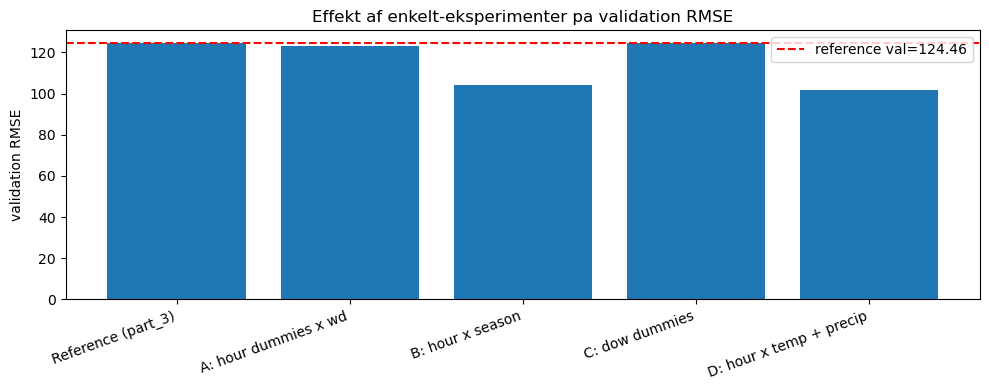

In [18]:
rows = [
    ("Reference (part_3)", ref_train, ref_val, ref_test),
    (res_A["label"], res_A["train"], res_A["val"], res_A["test"]),
    (res_B["label"], res_B["train"], res_B["val"], res_B["test"]),
    (res_C["label"], res_C["train"], res_C["val"], res_C["test"]),
    (res_D["label"], res_D["train"], res_D["val"], res_D["test"]),
]
header = f'{"model":35s} {"train":>8s} {"val":>8s} {"test":>8s} {"d val":>8s}'
print(header)
print("-" * len(header))
for lab, tr, va, te in rows:
    delta = va - ref_val
    print(f"{lab:35s} {tr:8.2f} {va:8.2f} {te:8.2f} {delta:+8.2f}")

labels = [r[0] for r in rows]
vals   = [r[2] for r in rows]
plt.figure(figsize=(10, 4))
plt.bar(range(len(labels)), vals)
plt.axhline(ref_val, color="red", linestyle="--", label=f"reference val={ref_val:.2f}")
plt.xticks(range(len(labels)), labels, rotation=20, ha="right")
plt.ylabel("validation RMSE")
plt.title("Effekt af enkelt-eksperimenter pa validation RMSE")
plt.legend(); plt.tight_layout(); plt.show()


## 9. Kombineret model — forward selection på udvidet feature-pulje

Tilføj de fire nye feature-grupper til `feature_groups` og kør forward selection på hele puljen. Bemærk at hour_dummies og hour-harmoniske overlapper i hvad de modellerer — forward selection vælger den bedste.


In [19]:
feature_groups_ext = dict(feature_groups)  # copy
feature_groups_ext["hour_dummies"]    = hour_dummy_feats
feature_groups_ext["hour_dummies_wd"] = hour_dummy_wd_feats
feature_groups_ext["hour_x_season"]   = hour_x_season_feats
feature_groups_ext["dow_dummies"]     = dow_dummy_feats
feature_groups_ext["hour_x_temp"]     = hour_x_temp_feats
feature_groups_ext["hour_x_precip"]   = hour_x_precip_feats

selected_groups_ext, selected_features_ext, history_ext = forward_select(
    feature_groups_ext, lam=0.0, verbose=True)
print(f"\nSelected groups (extended): {selected_groups_ext}")


(intercept only)           val RMSE = 259.81
hour_dummies_wd            val RMSE = 193.06
temp                       val RMSE = 146.58
hour_x_temp                val RMSE = 120.58
dayofyear_1                val RMSE = 113.04
temp_x_wd                  val RMSE = 107.72
hour_dummies               val RMSE = 102.64
hour_x_season              val RMSE = 99.47
wind_x_wd                  val RMSE = 97.90
temp_sq                    val RMSE = 96.61
precip_x_wd                val RMSE = 95.44
hour_x_precip              val RMSE = 95.02
dow_dummies                val RMSE = 94.71
log_precip                 val RMSE = 94.66
dayofyear_2                val RMSE = 94.62
wind                       val RMSE = 94.59
is_holiday                 val RMSE = 94.56
hour6_x_wd                 val RMSE = 94.53
wind_sq                    val RMSE = 94.52
is_raining                 val RMSE = 94.51
precip                     val RMSE = 94.50
is_weekend                 val RMSE = 94.50

Selected groups (extende

### λ-scan på den kombinerede model


Best lambda: 0, val RMSE: 94.50
OLS (lam=0)  val RMSE: 94.50


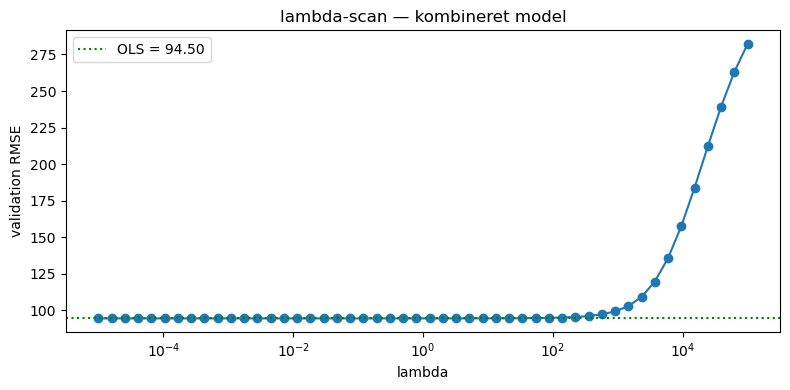

In [20]:
X_tr = build_X(df_training,   selected_features_ext)
X_va = build_X(df_validating, selected_features_ext)
X_te = build_X(df_testing,    selected_features_ext)
X_tr_s, mu_ext, sigma_ext = standardize_train(X_tr)
X_va_s = standardize_apply(X_va, mu_ext, sigma_ext)
X_te_s = standardize_apply(X_te, mu_ext, sigma_ext)

lambdas = np.concatenate([[0.0], np.logspace(-5, 5, 50)])
val_rmses = [calculate_RMSE(X_va_s, ridge_reg(X_tr_s, y_tr, lam), y_va) for lam in lambdas]
best_idx = int(np.argmin(val_rmses))
best_lam = lambdas[best_idx]
print(f"Best lambda: {best_lam:.6g}, val RMSE: {val_rmses[best_idx]:.2f}")
print(f"OLS (lam=0)  val RMSE: {val_rmses[0]:.2f}")

plt.figure(figsize=(8, 4))
plt.semilogx(lambdas[1:], val_rmses[1:], marker="o")
plt.axhline(val_rmses[0], color="green", linestyle=":", label=f"OLS = {val_rmses[0]:.2f}")
if best_lam > 0:
    plt.axvline(best_lam, color="red", linestyle="--", label=f"best lambda = {best_lam:.4g}")
plt.xlabel("lambda"); plt.ylabel("validation RMSE"); plt.legend()
plt.title("lambda-scan — kombineret model")
plt.tight_layout(); plt.show()


### Slutmodel — train, val, test


In [21]:
w_ext = ridge_reg(X_tr_s, y_tr, best_lam)
ext_train = calculate_RMSE(X_tr_s, w_ext, y_tr)
ext_val   = calculate_RMSE(X_va_s, w_ext, y_va)
ext_test  = calculate_RMSE(X_te_s, w_ext, y_te)

print(f"Reference (part_3)  train={ref_train:.2f}  val={ref_val:.2f}  test={ref_test:.2f}")
print(f"Combined (part_3b)  train={ext_train:.2f}  val={ext_val:.2f}  test={ext_test:.2f}")
print(f"d val: {ext_val - ref_val:+.2f}    d test: {ext_test - ref_test:+.2f}")


Reference (part_3)  train=114.12  val=124.46  test=124.18
Combined (part_3b)  train=85.93  val=94.50  test=94.47
d val: -29.96    d test: -29.71


### Residualer efter kombineret model — forsvandt time 8/17-strukturen?


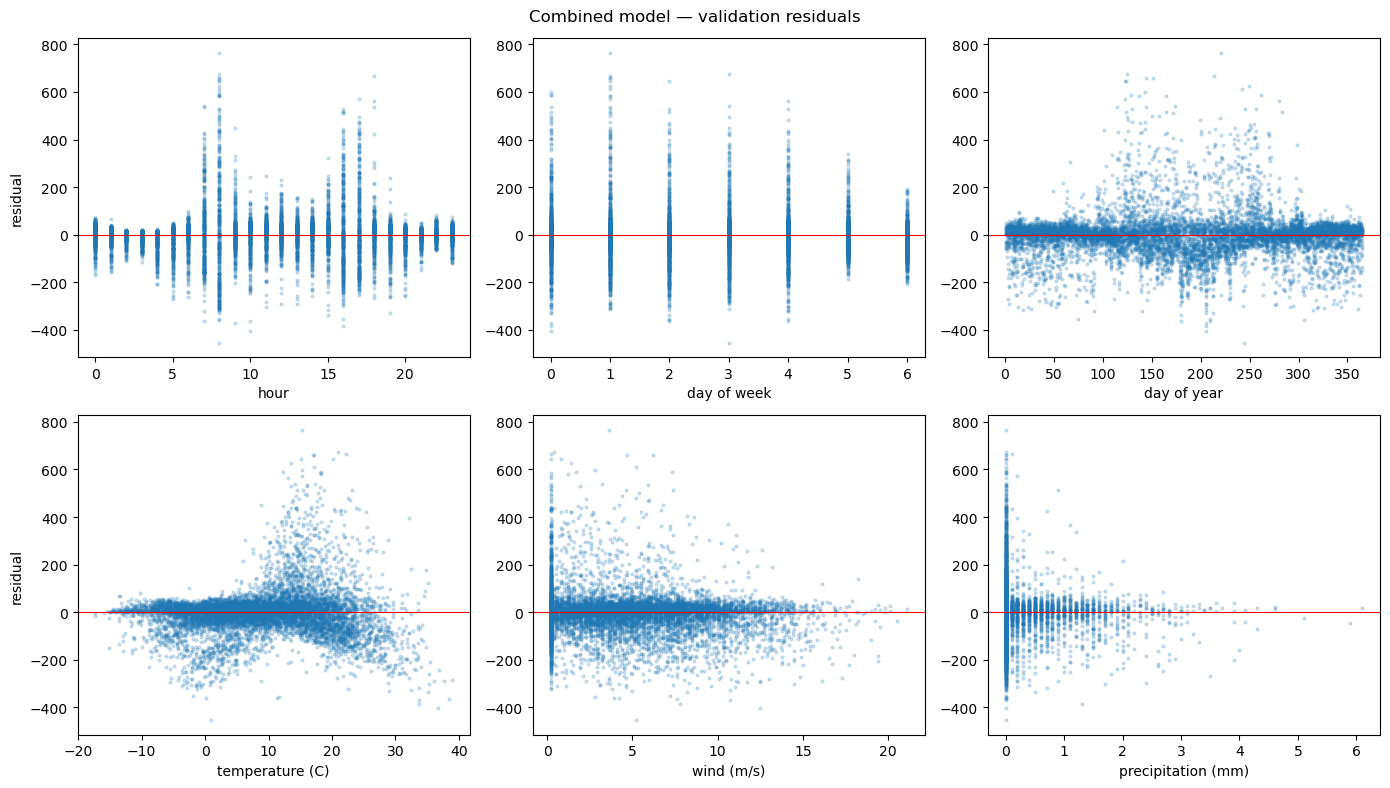

hour 8: ref MAE = 262.03, combined MAE = 194.78
hour 17: ref MAE = 197.62, combined MAE = 133.72


In [22]:
resid_ext_va = y_va - np.maximum((X_va_s @ w_ext).flatten(), 0)
plot_residuals(df_validating, resid_ext_va, "Combined model — validation residuals")

for target_hour in [8, 17]:
    mask = df_validating["datetime"].dt.hour == target_hour
    resid_h_ref = baseline_residuals_va[mask.values]
    resid_h_ext = resid_ext_va[mask.values]
    print(f"hour {target_hour}: ref MAE = {np.mean(np.abs(resid_h_ref)):.2f}, "
          f"combined MAE = {np.mean(np.abs(resid_h_ext)):.2f}")


### Coefficient-fortolkning


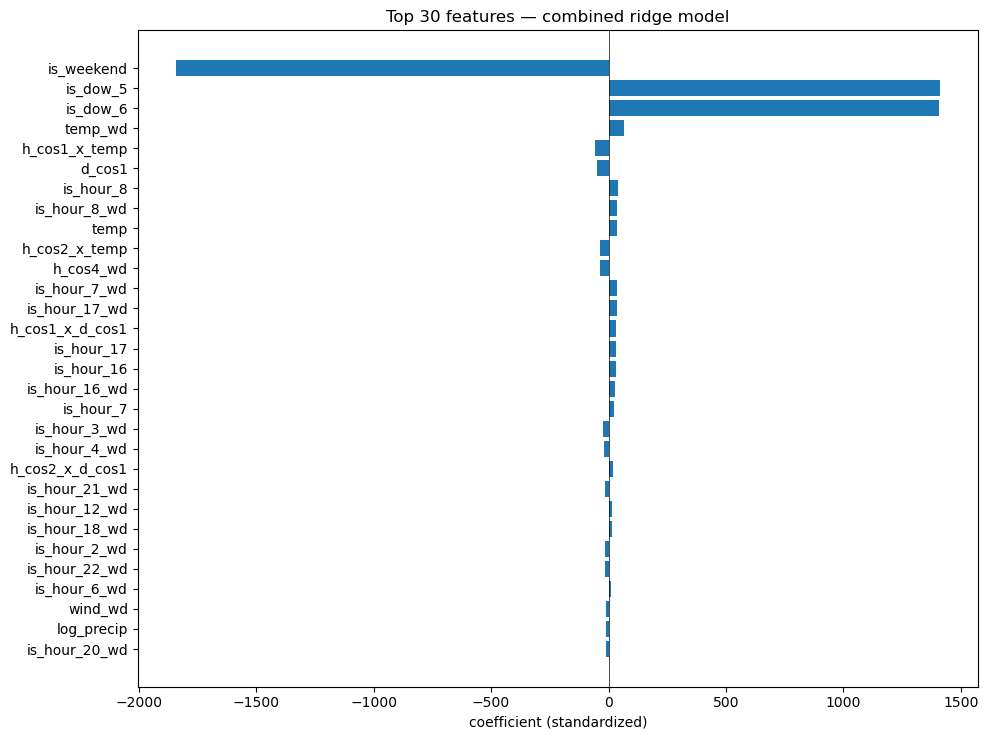

In [23]:
feat_labels_ext = ["intercept"] + selected_features_ext
coefs_ext = w_ext.flatten()
order = np.argsort(np.abs(coefs_ext[1:]))[::-1] + 1  # skip intercept
top_n = min(30, len(order))
order_top = order[:top_n]

plt.figure(figsize=(10, max(4, top_n * 0.25)))
plt.barh(np.array(feat_labels_ext)[order_top][::-1], coefs_ext[order_top][::-1])
plt.axvline(0, color="black", linewidth=0.5)
plt.xlabel("coefficient (standardized)")
plt.title(f"Top {top_n} features — combined ridge model")
plt.tight_layout(); plt.show()


## 10. Konklusion — den endelige models features og selektionsproces

### Resultat

Forward selection på den udvidede pulje (34 grupper) valgte **21 grupper / 93 features** + intercept. Slutmodel: λ=0 (ren OLS), **train RMSE = 85.93, val RMSE = 94.50, test RMSE = 94.47**. Δ test mod part_3-baseline (124.18) er **−29.71 (−24%)**. Ingen overfit (train ≈ test).

### Valgte grupper i selektionsrækkefølge

| # | Gruppe | Antal features | val RMSE efter |
|---|---|---|---|
| 1 | `hour_dummies_wd` | 23 (`is_hour_1_wd` … `is_hour_23_wd`) | 193.06 |
| 2 | `temp` | 1 | 146.58 |
| 3 | `hour_x_temp` | 4 (`h_{sin,cos}{1,2}_x_temp`) | 120.58 |
| 4 | `dayofyear_1` | 2 (`d_sin1`, `d_cos1`) | 113.04 |
| 5 | `temp_x_wd` | 1 (`temp_wd`) | 107.72 |
| 6 | `hour_dummies` | 23 (`is_hour_1` … `is_hour_23`) | 102.64 |
| 7 | `hour_x_season` | 16 (`h_{sin,cos}{1,2}_x_d_{sin,cos}{1,2}`) | 99.47 |
| 8 | `wind_x_wd` | 1 (`wind_wd`) | 97.90 |
| 9 | `temp_sq` | 1 | 96.61 |
| 10 | `precip_x_wd` | 1 (`precip_wd`) | 95.44 |
| 11 | `hour_x_precip` | 4 (`h_{sin,cos}{1,2}_x_precip`) | 95.02 |
| 12 | `dow_dummies` | 6 (`is_dow_1` … `is_dow_6`) | 94.71 |
| 13 | `log_precip` | 1 | 94.66 |
| 14 | `dayofyear_2` | 2 (`d_sin2`, `d_cos2`) | 94.62 |
| 15 | `wind` | 1 | 94.59 |
| 16 | `is_holiday` | 1 | 94.56 |
| 17 | `hour6_x_wd` | 2 (`h_sin4_wd`, `h_cos4_wd`) | 94.53 |
| 18 | `wind_sq` | 1 | 94.52 |
| 19 | `is_raining` | 1 | 94.51 |
| 20 | `precip` | 1 | 94.50 |
| 21 | `is_weekend` | 1 | 94.50 |

### Hvad blev fravalgt (13 grupper)

- **Alle 6 hour-harmoniske hovedeffekter** (`hour_24`, `hour_12`, `hour_8`, `hour_6`, `hour_4_8`, `hour_4`) — erstattet af `hour_dummies` der er mere fleksible (rammer hver time præcist i stedet for at superponere sin/cos)
- **5 af 6 hour-harmoniske × workday** (`hour24_x_wd`, `hour12_x_wd`, `hour8_x_wd`, `hour4_8_x_wd`, `hour4_x_wd`) — erstattet af `hour_dummies_wd`. Kun `hour6_x_wd` (k=4) overlevede; det giver et lille ekstra signal som dummies-interaktionerne ikke helt fanger
- `dayofweek` (sin/cos) — erstattet af `dow_dummies`
- `is_workday` indikatoren selv — interaktionerne (`*_wd`) bærer dens information

### Sådan blev de valgt

1. **Feature-pulje:** 34 grupper i alt = 28 originale fra part_3 (hour-harmoniske k=1..6, sæsonharmoniske, kalender, vejr, deres workday-interaktioner) + 6 nye eksperimentelle (hour-dummies, hour-dummies × workday, hour × season, dow-dummies, hour × temp, hour × precip)

2. **Standardisering:** Hver feature standardiseres med training-data's μ og σ. Intercept er urørt. Samme μ og σ anvendes på validation og test → ingen data-leakage

3. **Greedy forward selection (gruppe-baseret):**
   - Start: kun intercept, val RMSE = 259.81
   - Hvert skridt: prøv hver ikke-valgte gruppe, vælg den der sænker val RMSE mest
   - Stop når ingen gruppe forbedrer val RMSE
   - Rang-deficiente kombinationer (singular matrix — fx hvis både hour-harmoniske og hour-dummies findes i samme 24-dimensionelle hour-rum) returnerer `inf` og skippes naturligt

4. **Hvorfor grupper, ikke enkelte features:** sin/cos-par og interaktionsblokke er statistisk koblet. At vælge `h_sin1` uden `h_cos1` ville svare til at fastlægge en vilkårlig faseforskydning og er ikke tolkbart

5. **λ-tuning:** Efter forward selection scannes λ ∈ {0, 10⁻⁵, …, 10⁵}. **Best λ = 0** → ren OLS er optimal (n=8676 træningstimer ≫ p=93 features → regularisering ikke nødvendig)

6. **Slut-validering:** train (85.93) ≈ test (94.47) → ingen overfit. Test (94.47) ≈ val (94.50) → modelvalg generaliserer

### Resterende observationer

- **Time 8 og 17 residual-MAE er halveret** vs. reference: time 8 fra 262.03 → 194.78 (−26%), time 17 fra 197.62 → 133.72 (−32%)
- **Største enkeltbidrag** kom fra `hour_dummies_wd` (commute-pattern-præcision på workday) og `hour_x_temp` (vejr-effekt varierer over døgnet) — ikke fra `hour_x_season` alene som forventet
- **Kvadratiske vejr-led** (`temp_sq`, `wind_sq`) bidrog kun marginalt — vejrresponsen er nogenlunde lineær på timeligt niveau
- **Tilbage til Part 4 og 5:** station-specifikke effekter (Part 4) og lag-features (Part 5.B) er ikke afprøvet her
